# Finetuning pretrained - Gan 

I have used a pretrained model from kaggle that is made for 64\*64 images. So, I have scaled the images to 64\*64.

Moreover, in this file, I have used normalisation to \[-1,1\].

In [1]:
import pandas as pd
from PIL import Image
import torch 
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
splits = {'train': 'plain_text/train-00000-of-00001.parquet', 'test': 'plain_text/test-00000-of-00001.parquet'}
train_dataset = pd.read_parquet("hf://datasets/uoft-cs/cifar10/" + splits["train"])
test_dataset = pd.read_parquet("hf://datasets/uoft-cs/cifar10/" + splits["test"])

'The read operation timed out' thrown while requesting GET https://huggingface.co/datasets/uoft-cs/cifar10/resolve/main/plain_text/train-00000-of-00001.parquet
Retrying in 1s [Retry 1/5].


In [3]:
import torch 
from torch.utils.data import Dataset, DataLoader
from torch import nn
import io

In [4]:
class Cifar10Dataset(Dataset):
    def __init__(self, dataset ,input_transform, target_transform):
        self.x = [input_transform(dataset['img'][i]["bytes"]) for i in range(len(dataset['img']))]
        self.y = torch.LongTensor([target_transform(l) for l in dataset['label']])

    def __len__(self):
        return len(self.y)

    def __getitem__(self,idx):
        return self.x[idx], self.y[idx]

In [5]:
def input_transform(x):
    img = Image.open(io.BytesIO(x)).resize((64,64))
    d = torch.from_numpy(np.asarray(img,dtype=np.float32)).transpose(2,1).transpose(0,1)/255*2-1
    return d

In [6]:
train_data = Cifar10Dataset(train_dataset,input_transform,lambda x: x)
test_data = Cifar10Dataset(test_dataset,input_transform,lambda x: x)

## DCGAN

In [7]:
import torch.nn.functional as F
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        
        self.conv1 = nn.ConvTranspose2d(100, 64*8, 4, 1, 0, bias=False)
        self.bn1 = nn.BatchNorm2d(64*8)
        self.conv2 = nn.ConvTranspose2d(64*8, 64*4, 4, 2, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(64*4)
        self.conv3 = nn.ConvTranspose2d(64*4, 64*2, 4, 2, 1, bias=False)
        self.bn3 = nn.BatchNorm2d(64*2)
        self.conv4 = nn.ConvTranspose2d(64*2, 64, 4, 2, 1, bias=False)
        self.bn4 = nn.BatchNorm2d(64)
        
        self.conv5 = nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False)
        
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)), inplace=True)
        x = F.relu(self.bn2(self.conv2(x)), inplace=True)
        x = F.relu(self.bn3(self.conv3(x)), inplace=True)
        x = F.relu(self.bn4(self.conv4(x)), inplace=True)
        return torch.tanh(self.conv5(x))

In [8]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        
        self.conv1 = nn.Conv2d(3, 64, 4, 2, 1, bias=False)
        self.conv2 = nn.Conv2d(64, 64*2, 4, 2, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(64*2)
        self.conv3 = nn.Conv2d(64*2, 64*4, 4, 2, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(64*4)
        self.conv4 = nn.Conv2d(64*4, 64*8, 4, 2, 1, bias=False)
        self.bn3 = nn.BatchNorm2d(64*8)
        self.conv5 = nn.Conv2d(64*8, 1, 4, 1, 0, bias=False)
        
    def forward(self, x):
        x = F.leaky_relu(self.conv1(x), negative_slope=0.2, inplace=True)
        x = F.leaky_relu(self.bn1(self.conv2(x)), negative_slope=0.2, inplace=True)
        x = F.leaky_relu(self.bn2(self.conv3(x)), negative_slope=0.2, inplace=True)
        x = F.leaky_relu(self.bn3(self.conv4(x)), negative_slope=0.2, inplace=True)
        return torch.sigmoid(self.conv5(x))

In [9]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"

In [10]:
generator = Generator().to(device)
discriminator = Discriminator().to(device)

In [11]:
checkpoint = torch.load("./150epochs.chkpt", map_location=device)
generator.load_state_dict(checkpoint['generator_state_dict'])
discriminator.load_state_dict(checkpoint['discriminator_state_dict'])

<All keys matched successfully>

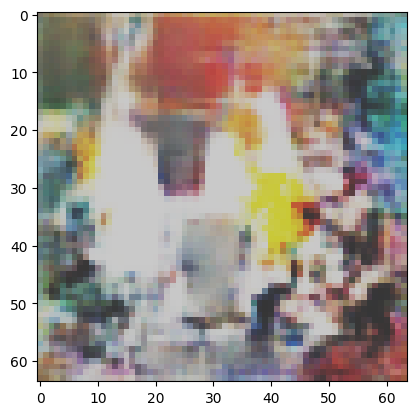

In [12]:
z = torch.randn((1,100,1,1)).to(device)
x = (generator(z)/(3**.5)+1)/2
plt.imshow(x.transpose(1,2).transpose(2,3)[0].detach().cpu().numpy())

In [13]:
discriminator(x),x.shape

(tensor([[[[0.0004]]]], device='cuda:0', grad_fn=<SigmoidBackward0>),
 torch.Size([1, 3, 64, 64]))

The above generator is made for 64\*64 and the discriminator is also made for 64\*64.
As we have 32*32, The images are scaled up.

In [14]:
batch_size = 700

train_dataloader = DataLoader(train_data,batch_size=batch_size)

In [15]:
import os
import gc

#os.mkdir("finetuning_pretrained_model2")
gc.collect()
torch.cuda.empty_cache()

In [16]:
max_epoch = 60

generator.train()
discriminator.train()

criterion = nn.BCELoss().to(device)
rgenerator = torch.Generator(device='cuda')


lr = 1e-5
beta1 = 0.5

generator_optim = torch.optim.Adam(generator.parameters(), lr=lr, betas=(beta1, 0.999))
discriminator_optim = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(beta1, 0.999))
generator_optim.load_state_dict(checkpoint['generator_optim_state_dict'])
discriminator_optim.load_state_dict(checkpoint['discriminator_optim_state_dict'])
for n in range(max_epoch):
    loss_ = 0
    D_t = 0
    for (x,y) in train_dataloader:
        discriminator_optim.zero_grad()
        x = x.to(device)
        y = y.to(device)
        labels = torch.ones((x.shape[0])).to(device)
        pred = discriminator(x).reshape(-1)
        D_t+=pred.sum()
        loss1 = criterion(pred,labels)
        loss_+=loss1.item()
        z = torch.randn((y.shape[0],100,1,1),generator = rgenerator,device = device)
        D_f = 0
        loss_2 = 0
        y = generator(z)
        pred = discriminator(y.detach()).reshape(-1)
        D_f+=pred.sum()
        labels = torch.zeros(y.shape[0]).to(device)
        loss2 = criterion(pred,labels)
        loss_ +=loss2.item()
        net_loss = loss1 + loss2
        net_loss.backward()
        discriminator_optim.step()
        generator_optim.zero_grad()
        pred = discriminator(y).reshape(-1)
        labels[:] = 1
        loss2 = criterion(pred,labels)
        loss2.backward()
        loss_2+=loss2.item()
        generator_optim.step()
    
    print(D_t.item()/len(train_data),D_f.item()/len(train_data))
    print(n,loss_,loss_2)
    if (n+1)%20 == 0:
        torch.save({
            'generator_state_dict': generator.state_dict(),
            'discriminator_state_dict': discriminator.state_dict(),
            'generator_optim_state_dict' : generator_optim.state_dict(),
            'discriminator_optim_state_dict' : discriminator_optim.state_dict(),}, f"finetuning_pretrained_model2/{n+1}epochs.chkpt")
    

0.827140546875 8.361981064081192e-07
0 61.20191135263303 1.4266496896743774
0.861313671875 0.0005782526779174804
1 31.07169149944093 3.266646385192871
0.893590546875 0.00047120162963867185
2 19.476176160387695 3.696864604949951
0.787545 0.0026969683837890627
3 85.8178232391549 2.8094937801361084
0.763001875 0.00045007217407226565
4 54.32501321006566 3.855050563812256
0.856288359375 0.000560097541809082
5 37.588278238268686 3.6095125675201416
0.8650203125 0.0004190642547607422
6 37.493007760553155 3.5629680156707764
0.928995546875 0.00045318016052246096
7 11.520494896918535 3.6336426734924316
0.83743546875 0.0005844770050048828
8 60.1521324361247 3.20093035697937
0.92194 0.0004457990264892578
9 13.021895315498114 3.7522432804107666
0.803701953125 0.0004777134704589844
10 60.70795931629982 3.4447543621063232
0.9439990625 0.0003059638595581055
11 8.885057168081403 3.969991445541382
0.86860609375 0.001335853271484375
12 42.826663396162985 3.233804702758789
0.688633984375 0.0014646658325195

*Ignore the below cell*

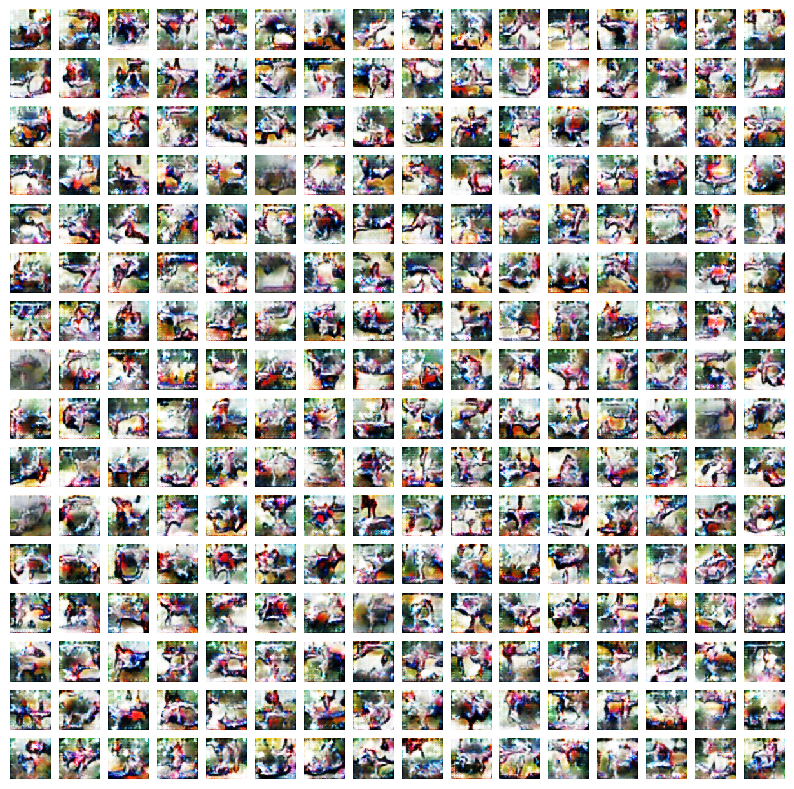

In [21]:
plt.figure(figsize=(10,10))
for i in range(256):
    ax = plt.subplot(16,16,i+1)
    image = generator(torch.randn((1,100,1,1)).to(device))
    image = (image+1)/2
    plt.imshow(torch.clamp(image,0,1).transpose(1,2).transpose(2,3)[0].detach().cpu().numpy(),interpolation = 'nearest')
    ax.axis("off")
plt.show()

As you can see the images, not very different but detailed. (Note the images seemed to share the same colour pallate as the original generator was trained for a small range of colours.)

Moreover the images are of similar group.